# How Music Describes Emotions?

## Research Question

Can Spotify audio features help describe the emotional character of music?

## Objective

This project investigates whether numerical audio features such as valence, energy, tempo, danceability, acousticness and loudness can provide insight into the emotional characteristics of songs.

--------

# Dataset Overview

The dataset contains Spotify audio features for 232,725 songs.

Each row represents one song, and each column represents a musical or metadata feature.

The goal of this section is to inspect the dataset structure before performing any analysis.

In [48]:
import pandas as pd

df = pd.read_csv("../data/SpotifyFeatures.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (232725, 18)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [49]:
df.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='str')

In [50]:
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  str    
 1   artist_name       232725 non-null  str    
 2   track_name        232724 non-null  str    
 3   track_id          232725 non-null  str    
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  str    
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  str    
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    232725 non-nu

### Dataset Summary

The dataset contains both metadata columns and numerical audio features.

Metadata columns such as artist name, track name, and track ID are useful for identification, but they are not directly used for numerical analysis.

The main audio features used in this project are Valence, Energy, Danceability, Tempo, Acousticness, Loudness, Speechiness, Instrumentalness, and Liveness.

------

# Distribution Analysis

Before studying relationships between features, it is important to understand how the main variables are distributed.

Histograms help show whether most songs have low, medium, or high values for features such as Valence, Energy, Danceability, and Tempo.

array([[<Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'energy'}>],
       [<Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'tempo'}>]], dtype=object)

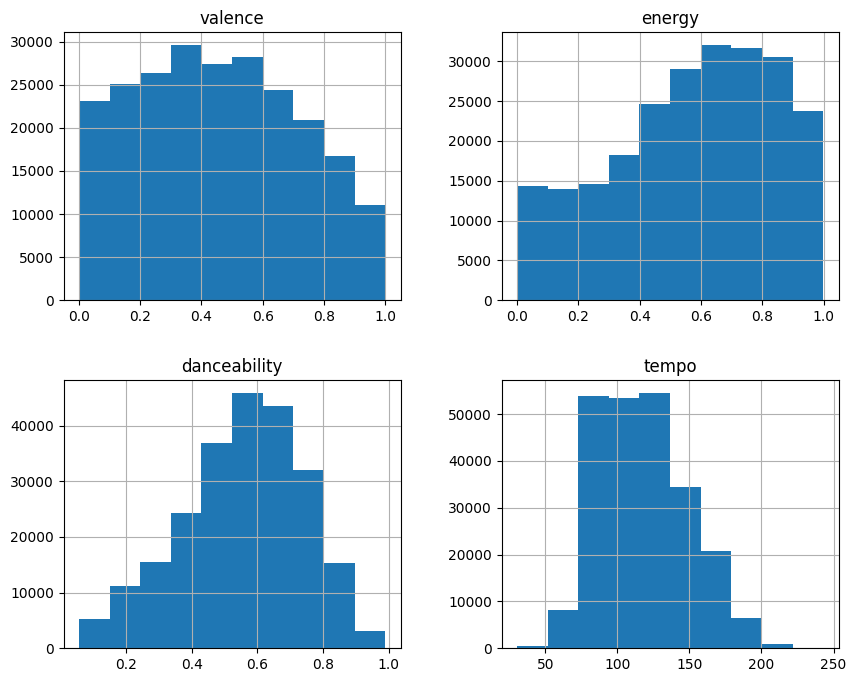

In [52]:
df[['valence', 'energy', 'danceability', 'tempo']].hist(figsize=(10, 8))

### Observation

Most songs have medium valence values rather than extremely positive or extremely negative emotional profiles.

Energy and Danceability are concentrated around medium-to-high values, while most songs fall between roughly 90 and 150 BPM in terms of tempo.

----

## Correlation Analysis

The next step is to investigate whether audio features move together.

Correlation measures the strength of the relationship between two variables and ranges from -1 to +1.

- Positive values indicate that two variables increase together.
- Negative values indicate that one variable decreases as the other increases.
- Values close to zero indicate little or no relationship.

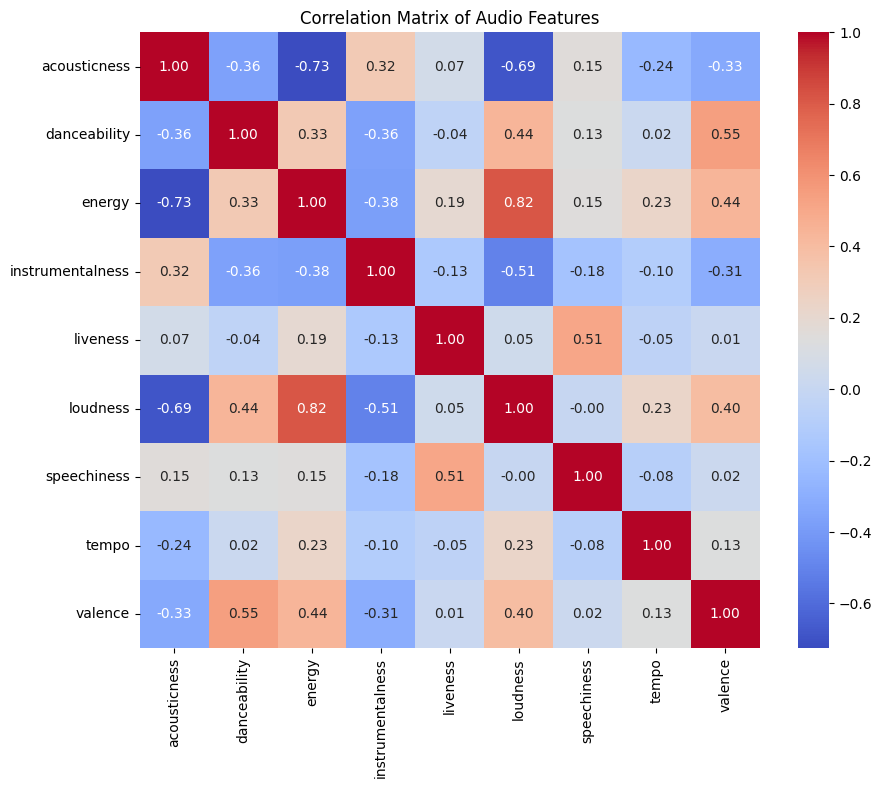

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_columns = [
    'acousticness',
    'danceability',
    'energy',
    'instrumentalness',
    'liveness',
    'loudness',
    'speechiness',
    'tempo',
    'valence'
]

corr_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Audio Features")
plt.show()

### Observation

Danceability shows the strongest positive relationship with Valence (0.55), followed by Energy (0.44).

Contrary to the initial expectation, Tempo exhibits only a weak relationship with Valence (0.13).

This suggests that positive emotional character may be associated more strongly with danceability and energy than with speed alone.

------

## Danceability vs Valence

Correlation values provide a numerical summary of relationships, 
but scatter plots allow us to visually inspect whether a relationship is 
actually visible in the data.

Each point in the graph represents one song.

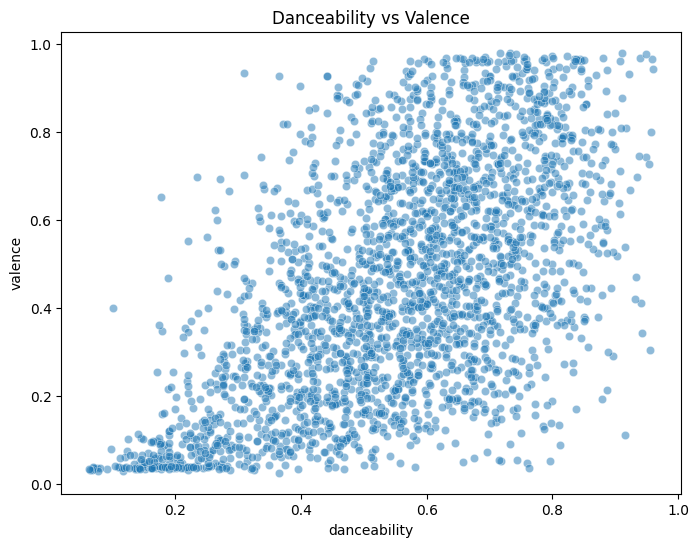

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(2500, random_state=50),
    x="danceability",
    y="valence",
    alpha=0.5
)

plt.title("Danceability vs Valence")
plt.show()

### Observation

A clear upward trend can be observed.

Songs with higher danceability generally tend to have higher valence values.

However, the relationship is not perfect, indicating that danceability alone cannot fully explain emotional positivity.

----

## Energy vs Valence

To compare the importance of different features, the relationship between Energy and Valence was also examined.

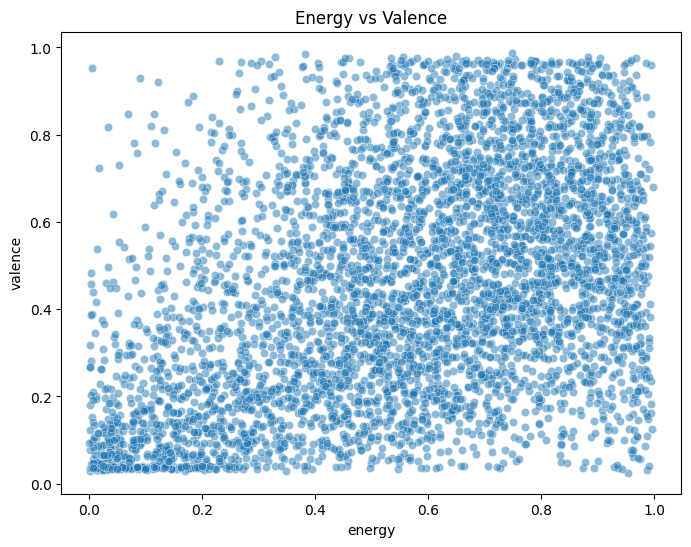

In [55]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(5000, random_state=50),
    x="energy",
    y="valence",
    alpha=0.5
)

plt.title("Energy vs Valence")
plt.show()

### Observation

Energy also shows a positive relationship with Valence.

However, the pattern appears more dispersed than the Danceability-Valence relationship.

One possible explanation is that some highly energetic genres, such as metal or aggressive rock music, may still express negative emotions.

------

### Preliminary Findings
One of the most surprising findings was that the relationship between energy and valence was weaker than expected.

Initially, I assumed that high-energy songs would generally have higher valence values. However, the correlation analysis showed only a moderate relationship (0.44).

A possible explanation is that some genres, such as metal or aggressive rock music, can have very high energy while still expressing negative, dark, or intense emotions, resulting in lower valence values.

-------------

## Valence-Based Song Groups

To better understand the relationship between emotional positivity and audio features, songs were divided into three groups based on their valence values.

- Low Valence (0.00 - 0.33)
- Medium Valence (0.33 - 0.66)
- High Valence (0.66 - 1.00)

This grouping allows us to compare the characteristics of songs with different emotional profiles.

In [56]:
import pandas as pd

df['valence_group'] = pd.cut(
    df['valence'],
    bins=[0, 0.33, 0.66, 1],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

df['valence_group'].value_counts()

valence_group
Medium    91481
Low       83159
High      58085
Name: count, dtype: int64

In [57]:
df.groupby("valence_group")[["energy", "danceability", "tempo"]].mean()

,energy,danceability,tempo
valence_group,,,
Low,0.428193,0.438544,113.124322
Medium,0.629426,0.588900,119.055554
High,0.683265,0.665790,121.982083


### Observation

Most songs in the dataset belong to the Medium and Low valence groups, while High valence songs are less common.

This suggests that the dataset is not dominated by extremely positive songs, which is consistent with the distribution observed in the earlier histogram analysis.

------------------

## Comparing Audio Features Across Valence Groups

After creating valence groups, the next step is to compare their average audio characteristics.

The goal is to determine whether songs with different emotional profiles also differ in terms of:

- Energy
- Danceability
- Tempo

If large differences exist, these features may help explain the emotional character of music.

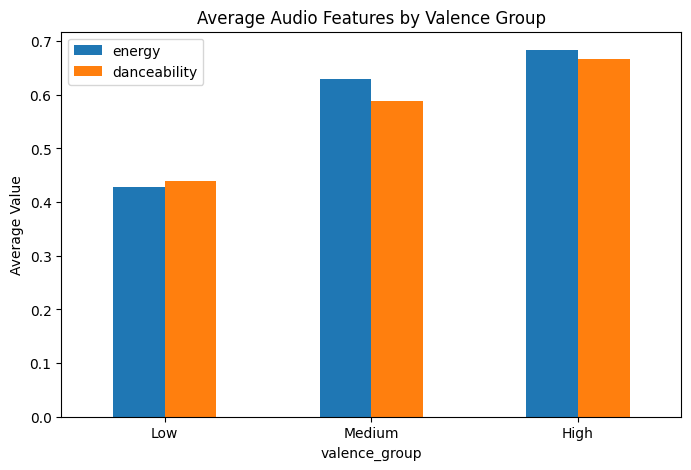

In [58]:
group_means = df.groupby("valence_group")[["energy", "danceability", "tempo"]].mean()

group_means[["energy", "danceability"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Audio Features by Valence Group")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

### Observation

Both Energy and Danceability increase substantially as valence increases.

| Valence Group | Energy | Danceability |
|--------------|----------|-------------|
| Low | 0.43 | 0.44 |
| Medium | 0.63 | 0.59 |
| High | 0.68 | 0.67 |

This indicates that songs with a more positive emotional character tend to be both more energetic and more danceable.

Tempo also increases slightly, but the difference is much smaller compared to Energy and Danceability.

---------

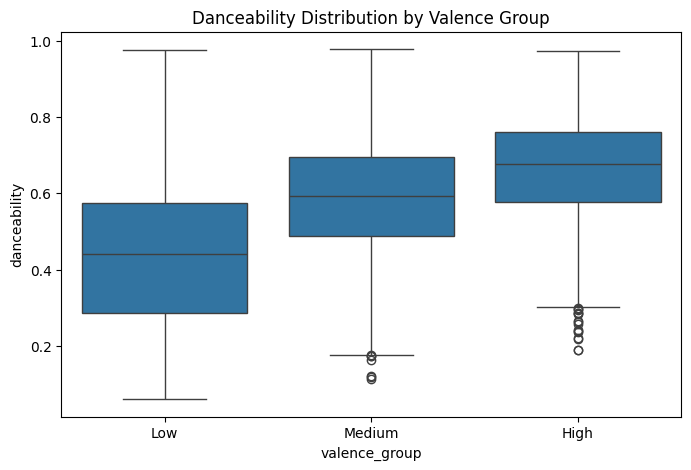

In [59]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df.sample(10000, random_state=42),
    x="valence_group",
    y="danceability"
)

plt.title("Danceability Distribution by Valence Group")
plt.show()

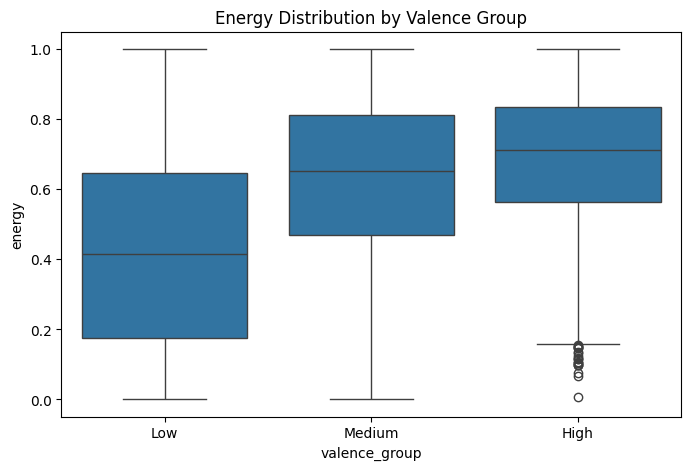

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df.sample(10000, random_state=42),
    x="valence_group",
    y="energy"
)

plt.title("Energy Distribution by Valence Group")
plt.show()

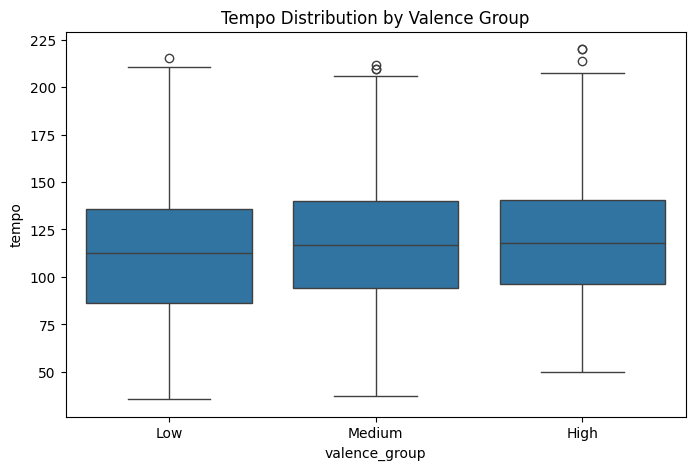

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df.sample(10000, random_state=42),
    x="valence_group",
    y="tempo"
)

plt.title("Tempo Distribution by Valence Group")
plt.show()

### Interpretation

Initially, I expected Energy to be the strongest indicator of positive emotions.

However, the analysis revealed that Danceability showed an even stronger relationship with Valence.

One possible explanation is that highly energetic songs are not always emotionally positive. Genres such as metal or aggressive rock music may have high energy levels while still expressing darker or more negative emotions.

-------

In [62]:
features = [
    'danceability',
    'energy',
    'tempo',
    'acousticness',
    'loudness',
    'speechiness',
    'instrumentalness',
    'liveness'
]

X = df[features]
y = df['valence']

print(X.shape)
print(y.shape)

(232725, 8)
(232725,)


# Preparing Data for Machine Learning

The selected audio features are used as input variables (X), while Valence is used as the target variable (y).

The dataset is then divided into training and testing sets to evaluate model performance on unseen data.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (186180, 8)
Test set: (46545, 8)


-------

# First Prediction Model: Linear Regression

After exploring the dataset, the next step is to test whether audio features can predict a song's valence score.

Linear Regression was selected as a baseline model because it is simple, interpretable, and widely used for numerical prediction tasks.

The objective is not to achieve perfect predictions, but to evaluate whether audio features contain meaningful information about emotional positivity.

In [64]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
predictions = model.predict(X_test)

predictions[:10]

array([0.40010445, 0.10955581, 0.66214515, 0.61832508, 0.47182555,
       0.53058442, 0.49467148, 0.64325037, 0.49549751, 0.58403454])

---

In [66]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print("R² Score:", round(r2, 4))

R² Score: 0.4112


---

# Model Comparison: Random Forest Regression

Linear Regression provides a simple baseline model.

However, emotional perception in music may depend on complex interactions between multiple audio features.

To capture potential non-linear relationships, a Random Forest Regressor is evaluated and compared with the baseline model.

In [67]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

----

In [68]:
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest R²:", round(rf_r2, 4))

Random Forest R²: 0.6756


---

# Model Evaluation Visualization

The R² score provides a numerical measure of model performance.

To better understand how well the Random Forest model performs, we compare predicted valence values with actual valence values.

If the model performs well, points should appear close to a diagonal line.

In [69]:
sample_size = 3000

sample_indices = y_test.sample(sample_size, random_state=42).index

actual = y_test.loc[sample_indices]
predicted = pd.Series(
    rf_predictions,
    index=y_test.index
).loc[sample_indices]

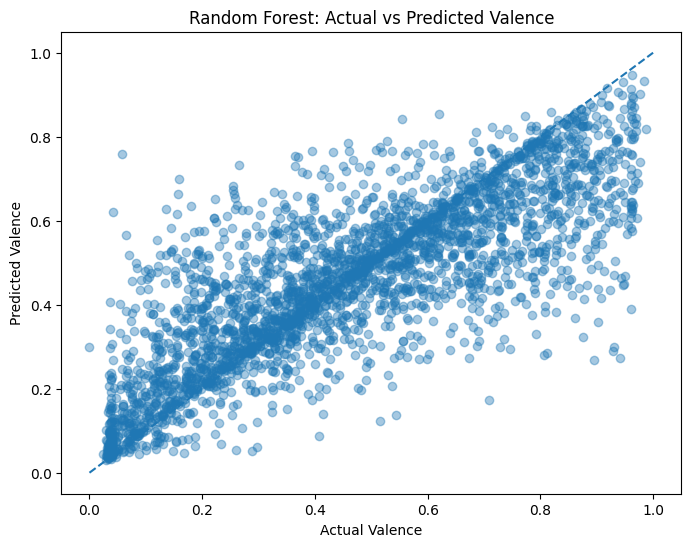

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    actual,
    predicted,
    alpha=0.4
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("Actual Valence")
plt.ylabel("Predicted Valence")
plt.title("Random Forest: Actual vs Predicted Valence")

plt.show()

# Feature Importance Analysis

After identifying the best-performing model, the next step is to investigate which audio features contribute most to predicting valence.

Feature importance helps explain the model's decisions and provides insights into which musical characteristics are most strongly associated with emotional positivity.

In [71]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,danceability,0.342982
1,energy,0.172670
5,speechiness,0.091813
2,tempo,0.088025
4,loudness,0.084879
3,acousticness,0.081905
7,liveness,0.078113
6,instrumentalness,0.059613


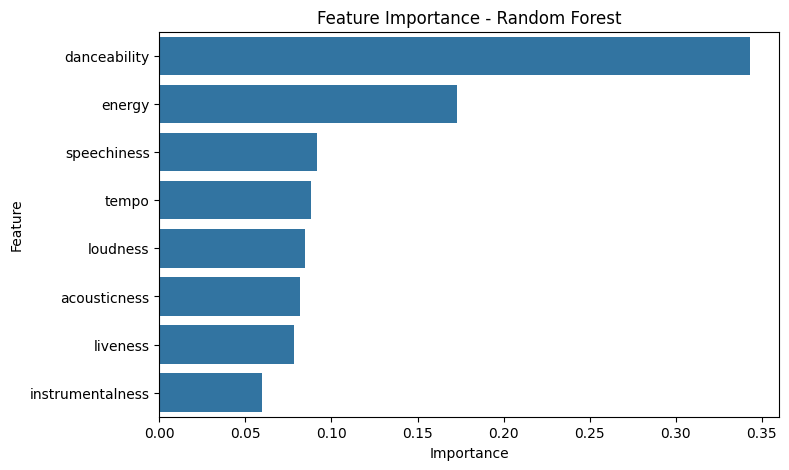

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.show()

---

## Feature Importance Findings

The Random Forest model identified Danceability as the most important predictor of Valence, followed by Energy.

This result is consistent with the earlier correlation analysis, scatter plots, and group comparisons.

Interestingly, Danceability appears to contribute more strongly to emotional positivity than Energy, suggesting that rhythmic and danceable characteristics may play a larger role in perceived positivity than raw intensity alone.

These findings support the hypothesis that numerical audio features contain meaningful information about emotional perception in music.

-----

# Introduction to Clustering

Regression helped predict valence values from audio features.

However, prediction is not the only goal.

Clustering is used to discover natural groups of songs that share similar characteristics.

Unlike Regression, clustering does not use emotional labels and instead searches for hidden patterns within the data.

---

In [73]:
cluster_data = df[['danceability', 'energy']]

cluster_data.head()

,danceability,energy
0,0.389,0.910
1,0.590,0.737
2,0.663,0.131
3,0.240,0.326
4,0.331,0.225


-------

# Determining the Number of Clusters

One of the most important decisions in K-Means clustering is selecting the number of clusters (K).

To make this decision objectively, the Elbow Method is used.

The idea is to compare different K values and identify the point where adding more clusters provides only small improvements.

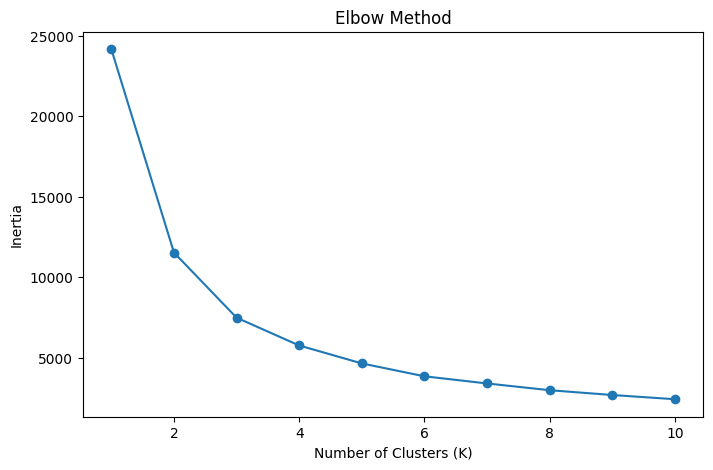

In [74]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_data)

    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, 11),
    inertia_values,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

-----

# K-Means Clustering

Based on the Elbow Method, K=3 was selected.

The goal is to identify natural groups of songs based on Danceability and Energy without using any emotional labels.

After clustering, the resulting groups will be analyzed and interpreted.

In [75]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_data)

df["cluster"] = clusters

In [76]:
df["cluster"].value_counts()

cluster
0    94205
2    86991
1    51529
Name: count, dtype: int64

In [77]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["danceability", "energy"]
)

centroids

,danceability,energy
0,0.553148,0.819777
1,0.341778,0.205449
2,0.681617,0.519443


------

## Cluster Visualization

The following plot shows the clusters discovered by K-Means using Danceability and Energy.

Each color represents a different cluster.

The goal is to visually inspect whether meaningful groups of songs emerge from the data.

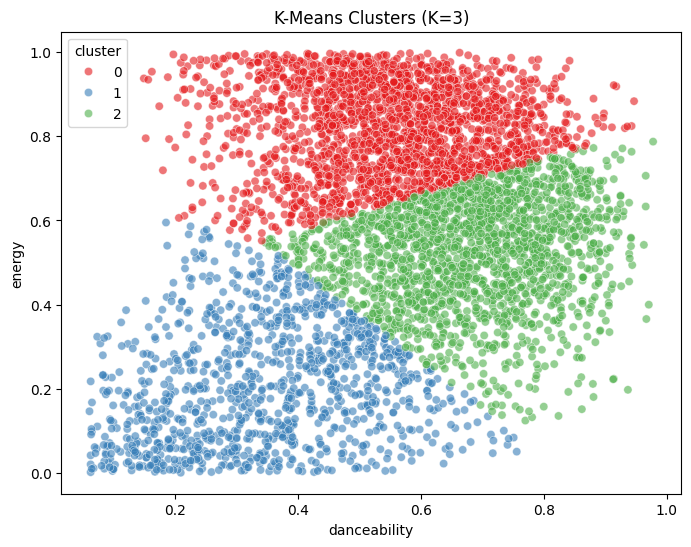

In [78]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="danceability",
    y="energy",
    hue="cluster",
    palette="Set1",
    alpha=0.6
)

plt.title("K-Means Clusters (K=3)")
plt.show()

## Cluster Interpretation

The clusters were created using only Danceability and Energy.

Valence was not included during clustering.

To understand whether the discovered groups also differ emotionally, the average Valence score of each cluster is examined.

In [79]:
df.groupby("cluster")[["valence", "danceability", "energy"]].mean()

,valence,danceability,energy
cluster,,,
0,0.532862,0.553254,0.819274
1,0.215644,0.341529,0.204976
2,0.512240,0.681640,0.518838


-----

# Genre Analysis of Clusters

After discovering clusters based on Danceability and Energy, the next step is to investigate which music genres appear most frequently in each cluster.

This helps connect the mathematical clustering results with real-world musical categories.

In [80]:
df[df["cluster"] == 0]["genre"].value_counts().head(10)

genre
Ska                 6974
Children’s Music    6348
Electronic          6128
Alternative         5863
Rock                5669
Comedy              5663
Reggaeton           5585
Anime               5566
Dance               4907
Country             4455
Name: count, dtype: int64

In [81]:
df[df["cluster"] == 1]["genre"].value_counts().head(10)

genre
Soundtrack          8503
Classical           8370
Opera               8146
Movie               4065
World               3444
Folk                2961
Jazz                2729
Anime               2126
Children’s Music    1723
Indie               1600
Name: count, dtype: int64

In [82]:
df[df["cluster"] == 2]["genre"].value_counts().head(10)

genre
Children’s Music    6685
Hip-Hop             5994
R&B                 5903
Rap                 5718
Soul                5610
Reggae              5364
Pop                 4658
Jazz                4591
Indie               4155
Folk                3650
Name: count, dtype: int64

### Cluster Interpretation by Genre

Cluster 0 contained many Electronic, Dance, and Rock-related genres characterized by high Energy.

Cluster 1 was dominated by genres such as Classical, Opera, and Soundtrack, which tend to have low Energy and low Valence.

Cluster 2 contained Hip-Hop, R&B, Rap, and Pop-related genres with high Danceability and moderate Energy.

Interestingly, genre information was not provided to the clustering algorithm. Despite this, the resulting clusters closely resemble recognizable musical categories.

In [83]:
df.groupby("genre")[
    ["valence", "energy", "danceability"]
].mean().sort_values(
    by="energy",
    ascending=False
).head(15)

,valence,energy,danceability
genre,,,
Ska,0.653472,0.815585,0.526799
Reggaeton,0.659439,0.748836,0.731260
Electronic,0.388129,0.739299,0.619542
Alternative,0.449590,0.711519,0.541898
Dance,0.517754,0.698067,0.638191
Rock,0.517113,0.683670,0.538292
Comedy,0.412764,0.676094,0.559038
Anime,0.441682,0.665356,0.472090
Rap,0.455918,0.650520,0.697244


In [84]:
df.groupby("genre")[
    ["valence", "energy", "danceability"]
].mean().sort_values(
    by="valence",
    ascending=False
).head(15)

,valence,energy,danceability
genre,,,
Reggae,0.679665,0.635749,0.699271
Reggaeton,0.659439,0.748836,0.731260
Ska,0.653472,0.815585,0.526799
Blues,0.579425,0.606171,0.528232
Country,0.535160,0.636318,0.577038
Children’s Music,0.532251,0.593204,0.598829
Dance,0.517754,0.698067,0.638191
Rock,0.517113,0.683670,0.538292
Jazz,0.508961,0.472776,0.585638


---------

In [85]:
df.groupby("genre")[
    ["valence", "energy", "danceability"]
].mean().sort_values(
    by="valence",
    ascending=True
).head(15)

,valence,energy,danceability
genre,,,
Soundtrack,0.118483,0.221110,0.265616
Opera,0.189864,0.168779,0.290650
Classical,0.214463,0.177984,0.305958
World,0.295657,0.506453,0.443293
A Capella,0.328724,0.250313,0.412252
Electronic,0.388129,0.739299,0.619542
Comedy,0.412764,0.676094,0.559038
Indie,0.428665,0.581002,0.566821
Folk,0.440237,0.491733,0.527276


-----

### Alternative Cluster Counts

The Elbow Method suggested that both K=3 and K=4 could be reasonable choices.

K=3 was selected because it provided a simpler and more interpretable solution while still capturing the major patterns in the data.

In [86]:
kmeans4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters4 = kmeans4.fit_predict(cluster_data)

df["cluster4"] = clusters4

df["cluster4"].value_counts()

cluster4
3    65132
0    63769
2    63506
1    40318
Name: count, dtype: int64

In [87]:
pd.DataFrame(
    kmeans4.cluster_centers_,
    columns=["danceability", "energy"]
)

,danceability,energy
0,0.615460,0.425729
1,0.300288,0.171700
2,0.479090,0.831562
3,0.725262,0.708290


---

# Genre Emotion Map

To connect the numerical analysis with recognizable music categories, the average Energy and Valence values were calculated for each genre.

In this visualization:

- X-axis represents Energy
- Y-axis represents Valence
- Each point represents one music genre

This helps show which genres are more energetic, more positive, calmer, or more melancholic

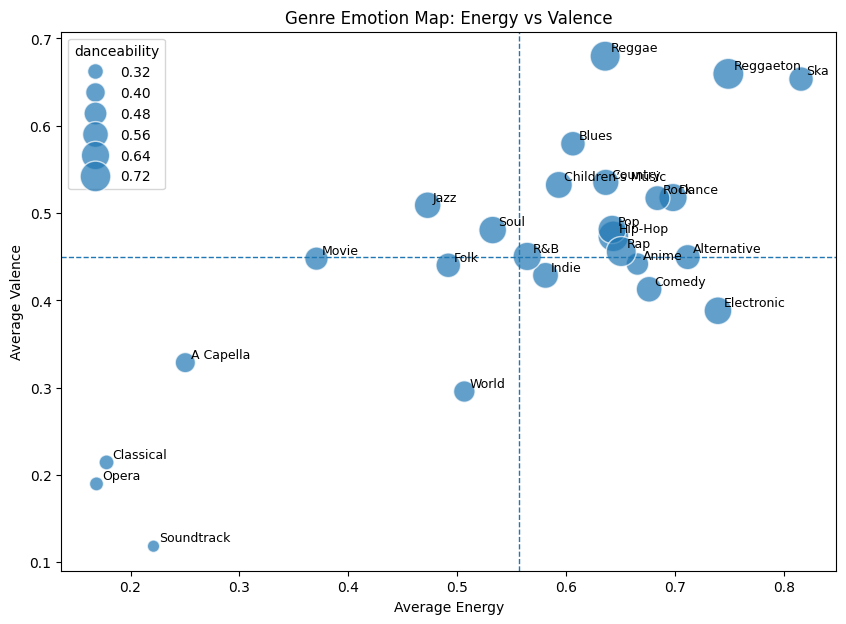

In [88]:
genre_means = df.groupby("genre")[["valence", "energy", "danceability"]].mean().reset_index()

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=genre_means,
    x="energy",
    y="valence",
    size="danceability",
    sizes=(80, 500),
    alpha=0.7
)

for i, row in genre_means.iterrows():
    plt.text(
        row["energy"] + 0.005,
        row["valence"] + 0.005,
        row["genre"],
        fontsize=9
    )

plt.axhline(genre_means["valence"].mean(), linestyle="--", linewidth=1)
plt.axvline(genre_means["energy"].mean(), linestyle="--", linewidth=1)

plt.title("Genre Emotion Map: Energy vs Valence")
plt.xlabel("Average Energy")
plt.ylabel("Average Valence")
plt.show()

### Observation

The genre map shows that high energy does not always mean high valence.

For example, Electronic music has high average energy but relatively low valence, while Reggae has both high valence and high danceability.

Soundtrack, Opera, and Classical music appear in the low-valence and low-energy region, which is consistent with the earlier clustering results.

This supports the idea that emotional positivity cannot be explained by a single feature such as Energy alone.

----

# Final Conclusions

------

## Main Findings

1. Numerical audio features contain meaningful information about emotional positivity in music.

2. Danceability consistently emerged as the strongest predictor of Valence across multiple analyses, including correlation analysis and Random Forest feature importance.

3. Energy was also an important feature, but high Energy did not always correspond to high Valence.

4. The Random Forest model achieved an R² score of approximately 0.67, indicating that a substantial portion of emotional positivity can be predicted from audio features.

5. K-Means clustering successfully discovered meaningful groups of songs without using emotional labels or genre information.

6. Genre analysis revealed that different musical styles occupy distinct regions of the Energy–Valence space.

## Limitations

1. The dataset relies on Spotify audio features and does not include lyrics, cultural context, or listener-specific preferences.

2. Emotional perception is highly subjective and may differ between individuals.

3. Valence is used as a proxy for emotional positivity, but it cannot fully represent the complexity of human emotions.

4. The analysis focuses on numerical audio features and does not consider harmonic structure, musical key interpretation, or lyrical content.

## Future Work

1. Investigate the impact of lyrics on emotional perception.

2. Explore additional machine learning models and compare their performance.

3. Analyze larger music datasets from multiple platforms such as Spotify and Apple Music.

4. Develop an emotion-based music recommendation system using the findings of this project.

5. Create an interactive dashboard that allows users to explore genres, emotions, and audio features in real time.